# LDSTOP Method: Applied to observables of Markov chains

This notebook accompanies the article **Stochastic optimisation method for estimating large deviations**.  
It demonstrates how the LDSTOP method can be used to estimate the large deviations of general observables of Markov chains.

**Author:** Daniël W. H. Cloete
**Date:** September 2026  
**Environment:** Python 3.12.3 (see `requirements.txt` / `runtime.txt`)

### Required packages download

In [ ]:
# %pip install -r ../requirements.txt

### Imports

In [1]:
# plotting
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
colors = ['#1f77b4', '#318c31', '#d62728']

# general
import numpy as np
import copy
from tqdm import tqdm

# torch
import torch
from torch.distributions import Multinomial
torch.set_default_dtype(torch.float64)

### LDSTOP method

In [3]:
def ldstop_MarkovChain(Pi, make_Pi_theta, theta, x0, g, k_min, k_max, delta_k, n, T, N, M, alpha):
    """
    Parameters:
        Pi            (torch.tensor): original process transition matrix
        make_Pi_theta (function):     function returning controlled transition matrix using theta
        theta         (torch.tensor): parameter set with requires_grad=True
        x0            (int):          initial state
        g             (function):     function in observable definition
        k_min         (float):        minimum k value
        k_max         (float):        maximum k value
        delta_k       (float):        k value increment
        n             (int):          number of independent parallel trajectories per epoch
        T             (int):          final time for each trajectory
        N             (int):          number of optimization epochs per k value
        M             (int):          number of final epochs estimates to construct final approximations
        alpha         (float):        initial learning rate for Adagrad optimizer

    Returns:
        I_est      (float array):       final rate function estimates
        A_est      (float array):       final observable value estimates
        SCGF_est   (float array):       final SCGF estimates
        ks         (float array):       corresponding k values
        theta_star (torch.tensor list): optimal parameter values
        As         (float array):       observable estimates over each optimization
        Ks         (float array):       KL divergence estimates over each optimization
        Ls         (float array):       loss estimates over each optimization
    """
    # number of k values
    num_ks = int(round(k_max/delta_k, 10)) + int(round(-k_min/delta_k, 10)) + 1
    # final estimate arrays
    I_est, A_est, SCGF_est, ks = np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks)
    theta_star = []
    # estimate tracking arrays
    As, Ks, Ls = np.zeros((num_ks, N)), np.zeros((num_ks, N)), np.zeros((num_ks, N))

    # initial k value
    k = 0
    k_index = 0

    # initial state
    x = torch.tensor(x0).repeat(n)

    # progress bar
    with tqdm(total=num_ks * N) as pbar:
        # k = 0 and positive k loop
        while k <= k_max:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad([theta], lr = alpha)

            for epoch in range(N):
                # arrays to track estimates, transition probabilities, trajectories
                A_t, K_t = torch.zeros(T, len(x)), torch.zeros(T, len(x))
                PTs = [None] * T
                Xis = [None] * T

                # generate n independent parallel trajectories using theta
                Pi_theta = make_Pi_theta(theta)
                for i in range(T):
                    pt = Multinomial(1, Pi_theta[x])
                    x_i = pt.sample((1,))
                    PTs[i] = pt
                    Xis[i] = x_i
                    x1 = torch.argmax(x_i, dim=2).squeeze(0)
                    A = g(x, x1)
                    K = (torch.log(Pi_theta[x,x1]/Pi[x,x1])).detach()
                    x = x1
                    A_t[i] = A
                    K_t[i] = K
                
                # score gradient computation
                grad_L = torch.zeros_like(theta)
                for i in range(T//2):
                    log_grad = torch.autograd.grad(((K_t[i:].mean(0) - k*A_t[i:].mean(0) - L_ave)*PTs[i].log_prob(Xis[i])).mean(), theta, retain_graph=True)[0]
                    grad_L += log_grad.clone()

                # SGD step
                theta.grad = grad_L
                optimizer.step()
                optimizer.zero_grad()

                # observable, KL divergence, loss estimates
                A_T, K_T = A_t.mean(), K_t.mean()
                L_T = K_T - k * A_T

                # record estimates
                As[k_index, epoch] = A_T
                Ks[k_index, epoch] = K_T
                Ls[k_index, epoch] = L_T

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(theta))

            # increment k
            k += delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

        # reinitialize k, theta, x
        k = -delta_k
        theta = copy.deepcopy(theta_star[0])
        x = torch.tensor(x0).repeat(n)

        # negative k loop
        while k >= k_min:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad([theta], lr = alpha)

            for epoch in range(N):
                # arrays to track estimates, transition probabilities, trajectories
                A_t, K_t = torch.zeros(T, len(x)), torch.zeros(T, len(x))
                PTs = [None] * T
                Xis = [None] * T

                # generate n independent parallel trajectories using theta
                Pi_theta = make_Pi_theta(theta)
                for i in range(T):
                    pt = Multinomial(1, Pi_theta[x])
                    x_i = pt.sample((1,))
                    PTs[i] = pt
                    Xis[i] = x_i
                    x1 = torch.argmax(x_i, dim=2).squeeze(0)
                    A = g(x, x1)
                    K = (torch.log(Pi_theta[x,x1]/Pi[x,x1])).detach()
                    x = x1
                    A_t[i] = A
                    K_t[i] = K
                
                # score gradient computation
                grad_L = torch.zeros_like(theta)
                for i in range(T//2):
                    log_grad = torch.autograd.grad(((K_t[i:].mean(0) - k*A_t[i:].mean(0) - L_ave)*PTs[i].log_prob(Xis[i])).mean(), theta, retain_graph=True)[0]
                    grad_L += log_grad.clone()

                # SGD step
                theta.grad = grad_L
                optimizer.step()
                optimizer.zero_grad()

                # observable, KL divergence, loss estimates
                A_T, K_T = A_t.mean(), K_t.mean()
                L_T = K_T - k * A_T

                # record estimates
                As[k_index, epoch] = A_T
                Ks[k_index, epoch] = K_T
                Ls[k_index, epoch] = L_T

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(theta))

            # decrement k
            k -= delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

    return I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls

### Results plotting function

In [4]:
def plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I = 0, SCGF = 0):
    # figure and subplots
    fig, axs = plt.subplots(3, 2, figsize=(9, 9))
    ax1, ax2 = axs[0]
    ax3, ax4 = axs[1]
    ax5, ax6 = axs[2]

    # rate function
    ax1.scatter(A_est, I_est, color=colors[2], marker='x', zorder=2)
    if I != 0:
        a_plot = np.linspace(np.min(A_est), np.max(A_est), 1000)
        ax1.plot(a_plot, I(a_plot), color='black', zorder=1)
    ax1.set_xlabel(r'$a$')
    ax1.set_ylabel(r'$I(a)$')
    ax1.spines['bottom'].set_position(('data', 0))
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # scaled cumulant generating function
    k_min = np.min(ks)
    k_max = np.max(ks)
    ax2.scatter(ks, SCGF_est, color=colors[0], marker='x', zorder=2)
    if SCGF != 0:
        k_plot = np.linspace(k_min, k_max, 1000)
        ax2.plot(k_plot, SCGF(k_plot), color='black', zorder=1)
    ax2.set_xlabel(r'$k$')
    ax2.set_ylabel(r'$\lambda(k)$')
    ax2.spines['bottom'].set_position(('data', 0))
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    col_i = [0 if k == 0 else 1 if k > 0 else 2 for k in ks]
    alphs = [1 if k == 0 else k/k_max if k > 0 else k/k_min for k in ks]

    # observable and KL estimates
    epochs = np.arange(1, len(As[0])+1)
    for i in range(len(As)):
        ax3.plot(epochs, As[i], color=colors[col_i[i]], alpha=alphs[i])
        ax4.plot(epochs, Ks[i], color=colors[col_i[i]], alpha=alphs[i])
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel(r'$A_T$')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel(r'$K_T$')

    # loss and scaled loss
    for i in range(len(As)):
        ax5.plot(epochs, Ls[i], color=colors[col_i[i]], alpha=alphs[i])
        ax6.plot(epochs, Ls[i] + SCGF_est[i], color=colors[col_i[i]], alpha=alphs[i])
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel(r'$L_T$')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel(r'Scaled $L_T$')

    fig.tight_layout(w_pad=3, rect=[0, 0, 1, 0.96])
    phi = (1 + np.sqrt(5)) / 2
    for ax in axs.flat:
        ax.set_box_aspect(1 / phi)
    return fig

### Symmetric binary Markov chain mean state

100%|██████████| 1550/1550 [00:32<00:00, 48.10it/s]


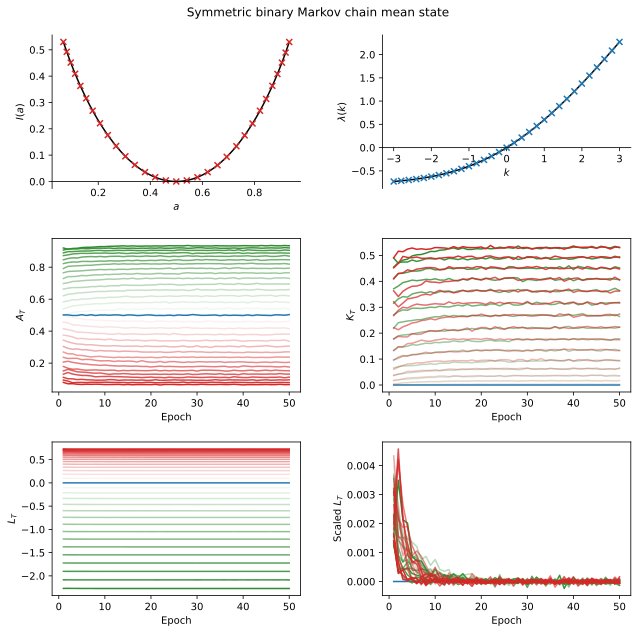

In [5]:
# problem parameters 
p = 0.55
Pi = torch.tensor([[1-p, p],[p, 1-p]])
def g(x0, x1):
    return x1

# algorithm parameters
def make_Pi_theta(theta):
    theta = torch.clamp(theta, 0.0, 1.0)
    return torch.stack([torch.stack([1-theta[0], theta[0]]),torch.stack([theta[1], 1-theta[1]])])

theta = torch.tensor([p, p], requires_grad=True)
x0 = 0
k_min = -3
k_max = 3
delta_k = 0.2
n = 2000
T = 25
N = 50
M = 30
alpha = 0.01

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_MarkovChain(Pi, make_Pi_theta, theta, x0, g, k_min, k_max, delta_k, n, T, N, M, alpha)

# true functions
def SCGF(k):
    return np.log((1 + np.exp(k) - p - np.exp(k)*p + np.sqrt((1 + np.exp(k))**2 * (p - 1)**2 + 4*np.exp(k)*(2*p - 1)))/2)

k = np.linspace(k_min - delta_k, k_max + delta_k, 5000)
scgf = [SCGF(k_i) for k_i in k]
a_k = np.gradient(scgf, k)
I_values = k * a_k - scgf
sorted_indices = np.argsort(a_k)
As_I = a_k[sorted_indices]
Is_I = I_values[sorted_indices]

def I(a):
    return np.interp(a, As_I, Is_I)

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Symmetric binary Markov chain mean state')
plt.show()

### Binary Markov chain activity

100%|██████████| 1550/1550 [00:36<00:00, 42.14it/s]


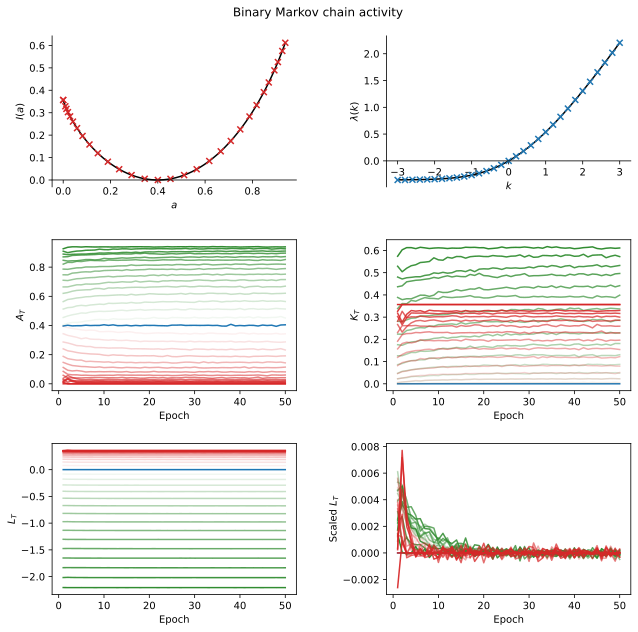

In [6]:
# problem parameters 
alp = 0.3
bet = 0.6
Pi = torch.tensor([[1-alp, alp],[bet, 1-bet]])
def g(x0, x1):
    return torch.round(torch.abs(x1-x0))

# algorithm parameters
def make_Pi_theta(theta):
    theta = torch.clamp(theta, 0.0, 1.0)
    return torch.stack([torch.stack([1-theta[0], theta[0]]),torch.stack([theta[1], 1-theta[1]])])

theta = torch.tensor([alp, bet], requires_grad=True)
x0 = 0
k_min = -3
k_max = 3
delta_k = 0.2
n = 2000
T = 25
N = 50
M = 30
alpha = 0.01

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_MarkovChain(Pi, make_Pi_theta, theta, x0, g, k_min, k_max, delta_k, n, T, N, M, alpha)

# true functions
def I(s):
    s = np.where(s == 0, 1e-10, s)
    s = np.where(s == 1, 1 - 1e-10, s)
    a = alp - bet
    b = alp + bet
    l = 1 / ((s - 1)**2)
    m = (l * s) / (alp * bet)
    w = np.sqrt((a**2) * (4 - 4 * s) + (s**2) * (b - 2)**2)
    i = (1/2) * s * np.log(m * (2*(a**2) - s*((alp**2) - 4 + alp*(4-6*bet) + bet*(4+bet)) + w*(2-b))) - np.log(-2*(-2+b) + np.sqrt(l*(4*(a**2) + 2*(s**2)*(b-2)**2 + 2*s*(-2*(a**2) + (2-b)*w)))) -(3/2)*s*np.log(2) + np.log(4)
    return i

def SCGF(k):
    return -np.log(2) + np.log(2 - alp - bet + np.sqrt(alp**2 - 2*alp*bet + 4*np.exp(2*k)*alp*bet + bet**2))

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Binary Markov chain activity')
plt.show()